In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib import cm
import os
import utils.saveload as sl

# Plot BIC

In [2]:
## Specify information for BIC ####################################################
n_sep = pd.DataFrame.from_dict({'B1': 1195, 'B2': 11, 'B3': 15, 'B4': 389, 'C1': 91, 'C3': 85, 'C6': 2183, 'C7': 359, 'C8': 39, 'C9': 469, 'B5': 401, 'B6': 79, 'B7': 1019, 'D3': 99, 'D4': 339, 'D5': 347, 'D6': 3, 'D7': 139, 'D8': 45, 'D9': 665}, orient='index', columns=['len']).reset_index().rename(columns={'index':'mouse_name'})
n_app = n_sep['len'].sum()

In [32]:
## Specify models to plot #########################################################
model_type_list     = ['hnor', 'multinov-eps_hnor','multinov-eps_hnor']
leakiness_type_list = ['leaky']*len(model_type_list)
kernel_type_list    = ['notrace']*len(model_type_list)
full_models_list    = [f'{lt}_{mt}_{kt}' if kt is not None else f'{lt}_{mt}' for lt, mt, kt in zip(leakiness_type_list, model_type_list, kernel_type_list)]
# level_list          = [[[1],[2],[3],[4],[5],[6]],
#                        [[5,6],[4,6],[3,6],[2,6],[1,6]]]
level_list          = [[[6]],
                       [[5,6], [4,6]]]
model_label_list    = ['Single\n', 'Combined\n', 'Combined\n']
level_label_list    = [['l=6'],
                        ['l=5,6', 'l=4,6']]
single_run_id_list  = ['_5','_3','_3'] # '', '_1', '_2', ... to distinguish multiple single runs with different initial conditions
comb_type           = 'app'
run_local           = True
seed_list           = [42957]
version             = 4


In [37]:
vmax   = 6
cnorm  = colors.Normalize(vmin=0, vmax=vmax)
cmap_b = plt.cm.get_cmap('Blues') # blue (single-distribution)
smap_b = cm.ScalarMappable(norm=cnorm, cmap=cmap_b)
cmap_r = plt.cm.get_cmap('Reds')  # red (two-distribution)
smap_r = cm.ScalarMappable(norm=cnorm, cmap=cmap_r)
color_list = [[smap_b.to_rgba(vmax-1)], [smap_r.to_rgba(vmax-1), smap_r.to_rgba(vmax-2)]]
model_class_list = [['single'],['combined', 'combined']]

trans_list = [[1]*len(color_list[0]),
              [1]*len(color_list[1])]

/var/folders/wv/411_cg655539_0t6mhrytx1w0000gp/T/ipykernel_1390/3421471637.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_b = plt.cm.get_cmap('Blues') # blue (single-distribution)
/var/folders/wv/411_cg655539_0t6mhrytx1w0000gp/T/ipykernel_1390/3421471637.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_r = plt.cm.get_cmap('Reds')  # red (two-distribution)


In [38]:
## Set paths to data files ########################################################
base_path       = str(sl.get_rootpath())
if run_local:
    # base_path_data = f'/Volumes/lcncluster/becker/RL_reward_novelty/data/MLE{version}_results/Fits/SingleRun/'
    # base_path_cv = f'/Volumes/lcncluster/becker/RL_reward_novelty/data/MLE{version}_results/Fits/CrossValidation_mouseid'
    base_path_data = f'/Users/sbecker/Projects/RL_reward_novelty/data/MLE{version}_results/Fits/SingleRun/'
    base_path_cv = f'/Users/sbecker/Projects/RL_reward_novelty/data/MLE{version}_results/Fits/CrossValidation_mouseid'
else:
    base_path_data  = os.path.join(base_path, f'data/MLE{version}_results/Fits/SingleRun/')
    base_path_cv  = os.path.join(base_path, f'data/MLE{version}_results/Fits/CrossValidation_mouseid/')

In [39]:
## Load fitting results for all models ############################################
info_fitted = []
for i, (model_type, leak_type, kernel_type, full_model, levels, sr_id) in enumerate(zip(model_type_list, leakiness_type_list, kernel_type_list, full_models_list, level_list, single_run_id_list)):

    LL_fitted_i  = []
    PP_fitted_i  = []
    BIC_fitted_i = []
    num_params_i = []
    labels_i     = []
    for j, level_j in enumerate(levels):

        if level_j is not None and kernel_type is not None:
            level_str   = '-'.join([str(lv) for lv in level_j]) if isinstance(level_j, list) else str(level_j)
        
        # Construct path to fitted model 
        if 'multinov-eps' in model_type:
            full_name   = f'mle_{leak_type}_{model_type}_{kernel_type}{sr_id}'
            fitted_path = os.path.join(base_path_data, full_name, f'mle_{leak_type}_{model_type}_{kernel_type}-l{level_str}_Nelder-Mead')
            fitted_file = f'mle_{leak_type}_{model_type}_{kernel_type}-l{level_str}_Nelder-Mead_{comb_type}.csv'
        elif kernel_type is not None and level_j is not None:
            full_name   = f'mle_{leak_type}_{model_type}_{kernel_type}-mice_Nelder-Mead{sr_id}'
            fitted_path = os.path.join(base_path_data, full_name, f'mle_{leak_type}_{model_type}_{kernel_type}-l{level_str}-mice_Nelder-Mead')
            fitted_file = f'mle_{leak_type}_{model_type}_{kernel_type}-l{level_str}-mice_Nelder-Mead_{comb_type}.csv'
        else:
            full_name       = f'mle_{leak_type}_{model_type}-mice_Nelder-Mead'
            fitted_path = os.path.join(base_path_data, full_name)
            fitted_file = f'mle_{leak_type}_{model_type}-mice_Nelder-Mead_{comb_type}.csv'

        # Load fitted model
        fitted_ij = sl.load_sim_data(fitted_path,file_data=fitted_file)

        # Extract LL / BIC 
        num_params_ij = len(fitted_ij.var_name.unique())
        penalty_ij    = num_params_ij * np.log(n_app)
        num_params_i.append(num_params_ij)
        LL_fitted_i.append(fitted_ij['mle_ll'].values[0])
        PP_fitted_i.append(penalty_ij)
        BIC_fitted_i.append(2*fitted_ij['mle_ll'].values[0] + penalty_ij)

        # Create label
        if level_j is not None:
            label_ij = f'{model_label_list[i]} ({level_label_list[i][j]})'
            labels_i.append(label_ij)
        else:
            labels_i.append(model_label_list[i])

    info_fitted_i = pd.DataFrame({'full_model': [full_model]*len(LL_fitted_i),
                                    'model_class': model_class_list[i][:len(LL_fitted_i)],
                                    'model_id': [i]*len(LL_fitted_i),
                                    'level': levels,
                                    'LL': LL_fitted_i,
                                    'PP': PP_fitted_i,
                                    'BIC': BIC_fitted_i,
                                    'color': color_list[i][:len(LL_fitted_i)],
                                    'trans': trans_list[i][:len(LL_fitted_i)],
                                    'label': labels_i})
    info_fitted.append(info_fitted_i)

info_fitted = pd.concat(info_fitted)

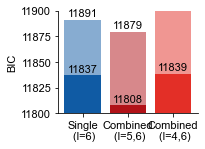

In [40]:
## Plot figure (fits + cv) ########################################################
# plt.rcParams.update({'font.size': 11}) 
plt.style.use('/Users/sbecker/Projects/RL_reward_novelty/src/scripts/Figures_Paper/paper.mplstyle')

path_save = os.path.join(sl.get_datapath().replace('data','output'),f'Figures_Paper_Revised/Fig_model_comp/')
sl.make_long_dir(path_save)

num_panels = 3
f, ax = plt.subplots(1,1,figsize=(8.3/num_panels,2)) # still need to set ratio differently (gridspec)

## Panel 1: Fits for single-distribution and two-distribution novelty
a_ll = ax.bar(np.arange(len(info_fitted)), 
              info_fitted['BIC'].values, 
              color=info_fitted['color'].values,
              alpha=0.5)
ax.bar_label(a_ll, fmt='%.f', label_type='edge', rotation='horizontal', padding=1)
a_pp = ax.bar(np.arange(len(info_fitted)), 
              2*info_fitted['LL'].values,
              color=info_fitted['color'].values, 
              alpha=1)
ax.bar_label(a_pp, fmt='%.f', label_type='edge', rotation='horizontal', padding=1)
ax.set_ylim([11800, 11900])
ax.spines[['top', 'right']].set_visible(False)
ax.set_xticks(np.arange(len(info_fitted)))
ax.set_xticklabels(info_fitted['label'].values)
ax.set_ylabel('BIC')

f.tight_layout(pad=0.4)
f.savefig(os.path.join(path_save, f'Rosenberg_bic-best_panels-{num_panels}.svg'))

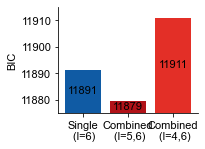

In [42]:
## Plot figure (fits + cv) ########################################################
# plt.rcParams.update({'font.size': 11}) 
plt.style.use('/Users/sbecker/Projects/RL_reward_novelty/src/scripts/Figures_Paper/paper.mplstyle')

path_save = os.path.join(sl.get_datapath().replace('data','output'),f'Figures_Paper_Revised/Fig_model_comp/')
sl.make_long_dir(path_save)

num_panels = 3
f, ax = plt.subplots(1,1,figsize=(8.3/num_panels,2)) # still need to set ratio differently (gridspec)

## Panel 1: Fits for single-distribution and two-distribution novelty
a_ll = ax.bar(np.arange(len(info_fitted)), 
              info_fitted['BIC'].values, 
              color=info_fitted['color'].values,
              alpha=1)
ax.bar_label(a_ll, fmt='%.f', label_type='center', rotation='horizontal', padding=1)
# ax.set_ylim([11875, 11895])
ax.set_ylim([11875, 11915])
ax.spines[['top', 'right']].set_visible(False)
ax.set_xticks(np.arange(len(info_fitted)))
ax.set_xticklabels(info_fitted['label'].values)
ax.set_ylabel('BIC')

f.tight_layout(pad=0.4)
f.savefig(os.path.join(path_save, f'Rosenberg_bic-simple-best_panels-{num_panels}.svg'))

# Plot BIC results for each model class

### Single level

In [25]:
plot_single = True

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib import cm
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import os
import sys
sys.path.append('/lcncluster/becker/RL_reward_novelty')
sys.path.append('/Users/sbecker/Projects/RL_reward_novelty')
import src.utils.saveload as sl

## Specify information for BIC ####################################################
n_sep = pd.DataFrame.from_dict({'B1': 1195, 'B2': 11, 'B3': 15, 'B4': 389, 'C1': 91, 'C3': 85, 'C6': 2183, 'C7': 359, 'C8': 39, 'C9': 469, 'B5': 401, 'B6': 79, 'B7': 1019, 'D3': 99, 'D4': 339, 'D5': 347, 'D6': 3, 'D7': 139, 'D8': 45, 'D9': 665}, orient='index', columns=['len']).reset_index().rename(columns={'index':'mouse_name'})
n_app = n_sep['len'].sum()

## Specify models to plot #########################################################

if plot_single:
    model_type_list     = ['hnor']
    model_label_list    = ['Single\n']
    level_list          = [[[1],[2],[3],[4],[5],[6]]]
    level_label_list    = [[f'l={ii[0]}' for ii in level_list[0]]]
    single_run_id_list  = ['_5']

else:
    model_type_list     = ['multinov-eps_hnor']
    model_label_list    = ['Combined\n']
    level_list          = [[[1,6],[2,6],[3,6],[4,6],[5,6]][::-1]]
    level_label_list    = [[f'l={",".join(map(str, ii))}' for ii in level_list[0]]]
    single_run_id_list  = ['_3']

leakiness_type_list = ['leaky']*len(model_type_list)
kernel_type_list    = ['notrace']*len(model_type_list)
full_models_list    = [f'{lt}_{mt}_{kt}' if kt is not None else f'{lt}_{mt}' for lt, mt, kt in zip(leakiness_type_list, model_type_list, kernel_type_list)]
comb_type           = 'app'
run_local           = True
seed_list           = [42957]
version             = 4

## Specify plotting parameters ####################################################
vmax   = len(level_list[0])
extra  = 2
cnorm  = colors.Normalize(vmin=0, vmax=vmax+extra) 
cmap_b = plt.cm.get_cmap('Blues') 
smap_b = cm.ScalarMappable(norm=cnorm, cmap=cmap_b) # blue (single distribution)
cmap_r = plt.cm.get_cmap('Reds')
smap_r = cm.ScalarMappable(norm=cnorm, cmap=cmap_r) # red (two-distribution nov.)

if plot_single:
    color_list = [[smap_b.to_rgba(i) for i in range(extra,extra+vmax)]]
    model_class_list = [['single']*len(color_list[0])] 
else:
    color_list = [[smap_r.to_rgba(i) for i in range(extra,extra+vmax)][::-1]]
    model_class_list = [['combined']*len(color_list[0])]

trans_list = [[1]*len(color_list[0])]

## Set paths to data files ########################################################
base_path       = str(sl.get_rootpath())
if run_local:
    # base_path_data = f'/Volumes/lcncluster/becker/RL_reward_novelty/data/MLE{version}_results/Fits/SingleRun/'
    # base_path_cv = f'/Volumes/lcncluster/becker/RL_reward_novelty/data/MLE{version}_results/Fits/CrossValidation_mouseid'
    base_path_data = f'/Users/sbecker/Projects/RL_reward_novelty/data/MLE{version}_results/Fits/SingleRun/'
    base_path_cv = f'/Users/sbecker/Projects/RL_reward_novelty/data/MLE{version}_results/Fits/CrossValidation_mouseid'
else:
    base_path_data  = os.path.join(base_path, f'data/MLE{version}_results/Fits/SingleRun/')
    base_path_cv  = os.path.join(base_path, f'data/MLE{version}_results/Fits/CrossValidation_mouseid/')

## Load fitting results for all models ############################################
info_fitted = []
for i, (model_type, leak_type, kernel_type, full_model, levels, sr_id) in enumerate(zip(model_type_list, leakiness_type_list, kernel_type_list, full_models_list, level_list, single_run_id_list)):

    LL_fitted_i  = []
    PP_fitted_i  = []
    BIC_fitted_i = []
    num_params_i = []
    labels_i     = []
    for j, level_j in enumerate(levels):

        if level_j is not None and kernel_type is not None:
            level_str   = '-'.join([str(lv) for lv in level_j]) if isinstance(level_j, list) else str(level_j)
        
        # Construct path to fitted model 
        if 'multinov-eps' in model_type:
            full_name   = f'mle_{leak_type}_{model_type}_{kernel_type}{sr_id}'
            fitted_path = os.path.join(base_path_data, full_name, f'mle_{leak_type}_{model_type}_{kernel_type}-l{level_str}_Nelder-Mead')
            fitted_file = f'mle_{leak_type}_{model_type}_{kernel_type}-l{level_str}_Nelder-Mead_{comb_type}.csv'
        elif kernel_type is not None and level_j is not None:
            full_name   = f'mle_{leak_type}_{model_type}_{kernel_type}-mice_Nelder-Mead{sr_id}'
            fitted_path = os.path.join(base_path_data, full_name, f'mle_{leak_type}_{model_type}_{kernel_type}-l{level_str}-mice_Nelder-Mead')
            fitted_file = f'mle_{leak_type}_{model_type}_{kernel_type}-l{level_str}-mice_Nelder-Mead_{comb_type}.csv'
        else:
            full_name       = f'mle_{leak_type}_{model_type}-mice_Nelder-Mead'
            fitted_path = os.path.join(base_path_data, full_name)
            fitted_file = f'mle_{leak_type}_{model_type}-mice_Nelder-Mead_{comb_type}.csv'

        # Load fitted model
        fitted_ij = sl.load_sim_data(fitted_path,file_data=fitted_file)

        # Extract LL / BIC 
        num_params_ij = len(fitted_ij.var_name.unique())
        penalty_ij    = num_params_ij * np.log(n_app)
        num_params_i.append(num_params_ij)
        LL_fitted_i.append(fitted_ij['mle_ll'].values[0])
        PP_fitted_i.append(penalty_ij)
        BIC_fitted_i.append(2*fitted_ij['mle_ll'].values[0] + penalty_ij)

        # Create label
        if level_j is not None:
            label_ij = level_label_list[i][j]
            labels_i.append(label_ij)
        else:
            labels_i.append(model_label_list[i])

    print(len(LL_fitted_i), len(model_class_list[i]), len(color_list[i]), len(trans_list[i]))
    info_fitted_i = pd.DataFrame({'full_model': [full_model]*len(LL_fitted_i),
                                    'model_class': model_class_list[i][:len(LL_fitted_i)+1],
                                    'model_id': [i]*len(LL_fitted_i),
                                    'level': levels,
                                    'LL': LL_fitted_i,
                                    'PP': PP_fitted_i,
                                    'BIC': BIC_fitted_i,
                                    'color': color_list[i][:len(LL_fitted_i)+1],
                                    'trans': trans_list[i][:len(LL_fitted_i)+1],
                                    'label': labels_i})
    info_fitted.append(info_fitted_i)

info_fitted = pd.concat(info_fitted)

6 6 6 6


/var/folders/wv/411_cg655539_0t6mhrytx1w0000gp/T/ipykernel_1390/65093999.py:48: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_b = plt.cm.get_cmap('Blues')
/var/folders/wv/411_cg655539_0t6mhrytx1w0000gp/T/ipykernel_1390/65093999.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_r = plt.cm.get_cmap('Reds')


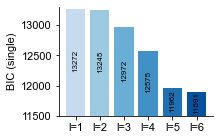

In [26]:
## Plot figure (fits + cv) ########################################################
plt.style.use('/Users/sbecker/Projects/RL_reward_novelty/src/scripts/Figures_Paper/paper.mplstyle')

path_save = os.path.join(sl.get_datapath().replace('data','output'),f'Figures_Paper_Revised/Fig_model_comp/')
sl.make_long_dir(path_save)

num_panels = 3
f, ax = plt.subplots(1,1, figsize=(8.3/num_panels,2)) # still need to set ratio differently (gridspec)

## Panel 1: Fits for single-distribution and two-distribution novelty
a_ll = ax.bar(np.arange(len(info_fitted)), 
              info_fitted['BIC'].values, 
              color=info_fitted['color'].values,
              alpha=1)
ax.bar_label(a_ll, fmt='%.f', label_type='center', rotation='vertical', padding=1, fontsize=8)
# a_pp = ax.bar(np.arange(len(info_fitted)), 
#               2*info_fitted['LL'].values,
#               color=info_fitted['color'].values, 
#               alpha=1)
# ax.bar_label(a_pp, fmt='%.f', label_type='center', rotation='vertical', padding=1)
# ax.set_ylim([11800, 11900])
ax.spines[['top', 'right']].set_visible(False)
ax.set_xticks(np.arange(len(info_fitted)))
ax.set_xticklabels(info_fitted['label'].values)
if plot_single:
    yl = 'BIC (single)'
    ylim = [11500, 13300]
    fig_name_add = 'single'
else:
    yl = 'BIC (combined)'
    ylim = [11850, 11930]
    fig_name_add = 'combined'

ax.set_ylabel(yl)
ax.set_ylim(ylim)
f.savefig(os.path.join(path_save, f'Rosenberg_bic-all-{fig_name_add}_panels-{num_panels}_reduced.svg'))

### Combined levels

In [28]:
plot_single = False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib import cm
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import os
import sys
sys.path.append('/lcncluster/becker/RL_reward_novelty')
sys.path.append('/Users/sbecker/Projects/RL_reward_novelty')
import src.utils.saveload as sl

## Specify information for BIC ####################################################
n_sep = pd.DataFrame.from_dict({'B1': 1195, 'B2': 11, 'B3': 15, 'B4': 389, 'C1': 91, 'C3': 85, 'C6': 2183, 'C7': 359, 'C8': 39, 'C9': 469, 'B5': 401, 'B6': 79, 'B7': 1019, 'D3': 99, 'D4': 339, 'D5': 347, 'D6': 3, 'D7': 139, 'D8': 45, 'D9': 665}, orient='index', columns=['len']).reset_index().rename(columns={'index':'mouse_name'})
n_app = n_sep['len'].sum()

## Specify models to plot #########################################################

if plot_single:
    model_type_list     = ['hnor']
    model_label_list    = ['Single\n']
    level_list          = [[[1],[2],[3],[4],[5],[6]]]
    level_label_list    = [[f'l={ii[0]}' for ii in level_list[0]]]
    single_run_id_list  = ['_5']

else:
    model_type_list     = ['multinov-eps_hnor']
    model_label_list    = ['Combined\n']
    level_list          = [[[1,6],[2,6],[3,6],[4,6],[5,6]][::-1]]
    level_label_list    = [[f'l={",".join(map(str, ii))}' for ii in level_list[0]]]
    single_run_id_list  = ['_3']

leakiness_type_list = ['leaky']*len(model_type_list)
kernel_type_list    = ['notrace']*len(model_type_list)
full_models_list    = [f'{lt}_{mt}_{kt}' if kt is not None else f'{lt}_{mt}' for lt, mt, kt in zip(leakiness_type_list, model_type_list, kernel_type_list)]
comb_type           = 'app'
run_local           = True
seed_list           = [42957]
version             = 4

## Specify plotting parameters ####################################################
vmax   = len(level_list[0])
extra  = 2
cnorm  = colors.Normalize(vmin=0, vmax=vmax+extra) 
cmap_b = plt.cm.get_cmap('Blues') 
smap_b = cm.ScalarMappable(norm=cnorm, cmap=cmap_b) # blue (single distribution)
cmap_r = plt.cm.get_cmap('Reds')
smap_r = cm.ScalarMappable(norm=cnorm, cmap=cmap_r) # red (two-distribution nov.)

if plot_single:
    color_list = [[smap_b.to_rgba(i) for i in range(extra,extra+vmax)]]
    model_class_list = [['single']*len(color_list[0])] 
else:
    color_list = [[smap_r.to_rgba(i) for i in range(extra,extra+vmax)][::-1]]
    model_class_list = [['combined']*len(color_list[0])]

trans_list = [[1]*len(color_list[0])]

## Set paths to data files ########################################################
base_path       = str(sl.get_rootpath())
if run_local:
    # base_path_data = f'/Volumes/lcncluster/becker/RL_reward_novelty/data/MLE{version}_results/Fits/SingleRun/'
    # base_path_cv = f'/Volumes/lcncluster/becker/RL_reward_novelty/data/MLE{version}_results/Fits/CrossValidation_mouseid'
    base_path_data = f'/Users/sbecker/Projects/RL_reward_novelty/data/MLE{version}_results/Fits/SingleRun/'
    base_path_cv = f'/Users/sbecker/Projects/RL_reward_novelty/data/MLE{version}_results/Fits/CrossValidation_mouseid'
else:
    base_path_data  = os.path.join(base_path, f'data/MLE{version}_results/Fits/SingleRun/')
    base_path_cv  = os.path.join(base_path, f'data/MLE{version}_results/Fits/CrossValidation_mouseid/')

## Load fitting results for all models ############################################
info_fitted = []
for i, (model_type, leak_type, kernel_type, full_model, levels, sr_id) in enumerate(zip(model_type_list, leakiness_type_list, kernel_type_list, full_models_list, level_list, single_run_id_list)):

    LL_fitted_i  = []
    PP_fitted_i  = []
    BIC_fitted_i = []
    num_params_i = []
    labels_i     = []
    for j, level_j in enumerate(levels):

        if level_j is not None and kernel_type is not None:
            level_str   = '-'.join([str(lv) for lv in level_j]) if isinstance(level_j, list) else str(level_j)
        
        # Construct path to fitted model 
        if 'multinov-eps' in model_type:
            full_name   = f'mle_{leak_type}_{model_type}_{kernel_type}{sr_id}'
            fitted_path = os.path.join(base_path_data, full_name, f'mle_{leak_type}_{model_type}_{kernel_type}-l{level_str}_Nelder-Mead')
            fitted_file = f'mle_{leak_type}_{model_type}_{kernel_type}-l{level_str}_Nelder-Mead_{comb_type}.csv'
        elif kernel_type is not None and level_j is not None:
            full_name   = f'mle_{leak_type}_{model_type}_{kernel_type}-mice_Nelder-Mead{sr_id}'
            fitted_path = os.path.join(base_path_data, full_name, f'mle_{leak_type}_{model_type}_{kernel_type}-l{level_str}-mice_Nelder-Mead')
            fitted_file = f'mle_{leak_type}_{model_type}_{kernel_type}-l{level_str}-mice_Nelder-Mead_{comb_type}.csv'
        else:
            full_name       = f'mle_{leak_type}_{model_type}-mice_Nelder-Mead'
            fitted_path = os.path.join(base_path_data, full_name)
            fitted_file = f'mle_{leak_type}_{model_type}-mice_Nelder-Mead_{comb_type}.csv'

        # Load fitted model
        fitted_ij = sl.load_sim_data(fitted_path,file_data=fitted_file)

        # Extract LL / BIC 
        num_params_ij = len(fitted_ij.var_name.unique())
        penalty_ij    = num_params_ij * np.log(n_app)
        num_params_i.append(num_params_ij)
        LL_fitted_i.append(fitted_ij['mle_ll'].values[0])
        PP_fitted_i.append(penalty_ij)
        BIC_fitted_i.append(2*fitted_ij['mle_ll'].values[0] + penalty_ij)

        # Create label
        if level_j is not None:
            label_ij = level_label_list[i][j]
            labels_i.append(label_ij)
        else:
            labels_i.append(model_label_list[i])

    print(len(LL_fitted_i), len(model_class_list[i]), len(color_list[i]), len(trans_list[i]))
    info_fitted_i = pd.DataFrame({'full_model': [full_model]*len(LL_fitted_i),
                                    'model_class': model_class_list[i][:len(LL_fitted_i)+1],
                                    'model_id': [i]*len(LL_fitted_i),
                                    'level': levels,
                                    'LL': LL_fitted_i,
                                    'PP': PP_fitted_i,
                                    'BIC': BIC_fitted_i,
                                    'color': color_list[i][:len(LL_fitted_i)+1],
                                    'trans': trans_list[i][:len(LL_fitted_i)+1],
                                    'label': labels_i})
    info_fitted.append(info_fitted_i)

info_fitted = pd.concat(info_fitted)

5 5 5 5


/var/folders/wv/411_cg655539_0t6mhrytx1w0000gp/T/ipykernel_1390/2969317658.py:48: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_b = plt.cm.get_cmap('Blues')
/var/folders/wv/411_cg655539_0t6mhrytx1w0000gp/T/ipykernel_1390/2969317658.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_r = plt.cm.get_cmap('Reds')


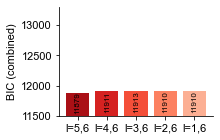

In [29]:
## Plot figure (fits + cv) ########################################################
plt.style.use('/Users/sbecker/Projects/RL_reward_novelty/src/scripts/Figures_Paper/paper.mplstyle')

path_save = os.path.join(sl.get_datapath().replace('data','output'),f'Figures_Paper_Revised/Fig_model_comp/')
sl.make_long_dir(path_save)

num_panels = 3
f, ax = plt.subplots(1,1, figsize=(8.3/num_panels,2)) # still need to set ratio differently (gridspec)

## Panel 1: Fits for single-distribution and two-distribution novelty
a_ll = ax.bar(np.arange(len(info_fitted)), 
              info_fitted['BIC'].values, 
              color=info_fitted['color'].values,
              alpha=1)
ax.bar_label(a_ll, fmt='%.f', label_type='center', rotation='vertical', padding=1, fontsize=8)
# a_pp = ax.bar(np.arange(len(info_fitted)), 
#               2*info_fitted['LL'].values,
#               color=info_fitted['color'].values, 
#               alpha=1)
# ax.bar_label(a_pp, fmt='%.f', label_type='center', rotation='vertical', padding=1)
# ax.set_ylim([11800, 11900])
ax.spines[['top', 'right']].set_visible(False)
ax.set_xticks(np.arange(len(info_fitted)))
ax.set_xticklabels(info_fitted['label'].values)
if plot_single:
    yl = 'BIC (single)'
    ylim = [11500, 13300]
    fig_name_add = 'single'
else:
    yl = 'BIC (combined)'
    ylim = [11500, 13300]
    # ylim = [11850, 11930]
    fig_name_add = 'combined'

ax.set_ylabel(yl)
ax.set_ylim(ylim)
f.savefig(os.path.join(path_save, f'Rosenberg_bic-all-{fig_name_add}_panels-{num_panels}_reduced.svg'))

### Both together (with zoom inset)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib import cm
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import os
import sys
sys.path.append('/lcncluster/becker/RL_reward_novelty')
sys.path.append('/Users/sbecker/Projects/RL_reward_novelty')
import src.utils.saveload as sl

## Specify information for BIC ####################################################
n_sep = pd.DataFrame.from_dict({'B1': 1195, 'B2': 11, 'B3': 15, 'B4': 389, 'C1': 91, 'C3': 85, 'C6': 2183, 'C7': 359, 'C8': 39, 'C9': 469, 'B5': 401, 'B6': 79, 'B7': 1019, 'D3': 99, 'D4': 339, 'D5': 347, 'D6': 3, 'D7': 139, 'D8': 45, 'D9': 665}, orient='index', columns=['len']).reset_index().rename(columns={'index':'mouse_name'})
n_app = n_sep['len'].sum()

## Specify models to plot #########################################################

# Single level
model_type_list     = ['hnor']
model_label_list    = ['Single\n']
level_list          = [[[1],[2],[3],[4],[5],[6]]]
level_label_list    = [[f'l={ii[0]}' for ii in level_list[0]]]
single_run_id_list  = ['_5']

# Multiple level
model_type_list     += ['multinov-eps_hnor']
model_label_list    += ['Combined\n']
level_list          += [[[1,6],[2,6],[3,6],[4,6],[5,6]][::-1]]
level_label_list    += [[f'l={",".join(map(str, ii))}' for ii in level_list[0]]]
single_run_id_list  += ['_3']

leakiness_type_list = ['leaky']*len(model_type_list)
kernel_type_list    = ['notrace']*len(model_type_list)
full_models_list    = [f'{lt}_{mt}_{kt}' if kt is not None else f'{lt}_{mt}' for lt, mt, kt in zip(leakiness_type_list, model_type_list, kernel_type_list)]
comb_type           = 'app'
run_local           = True
seed_list           = [42957]
version             = 4

## Specify plotting parameters ####################################################
vmax   = len(level_list[0])
extra  = 2
cnorm  = colors.Normalize(vmin=0, vmax=vmax+extra) 
cmap_b = plt.cm.get_cmap('Blues') 
smap_b = cm.ScalarMappable(norm=cnorm, cmap=cmap_b) # blue (single distribution)
cmap_r = plt.cm.get_cmap('Reds')
smap_r = cm.ScalarMappable(norm=cnorm, cmap=cmap_r) # red (two-distribution nov.)

color_list  = [[smap_b.to_rgba(i) for i in range(extra,extra+vmax)]]
color_list += [[smap_r.to_rgba(i) for i in range(extra,extra+vmax)][::-1]]

model_class_list    = [['single']*len(color_list[0]), ['combined']*len(color_list[1])] 
trans_list          = [[1]*len(color_list[0]), [1]*len(color_list[1])]

## Set paths to data files ########################################################
base_path       = str(sl.get_rootpath())
if run_local:
    base_path_data = f'/Volumes/lcncluster/becker/RL_reward_novelty/data/MLE{version}_results/Fits/SingleRun/'
    base_path_cv = f'/Volumes/lcncluster/becker/RL_reward_novelty/data/MLE{version}_results/Fits/CrossValidation_mouseid'
    # base_path_data = f'/Users/sbecker/Projects/RL_reward_novelty/data/MLE{version}_results/Fits/SingleRun/'
    # base_path_cv = f'/Users/sbecker/Projects/RL_reward_novelty/data/MLE{version}_results/Fits/CrossValidation_mouseid'
else:
    base_path_data  = os.path.join(base_path, f'data/MLE{version}_results/Fits/SingleRun/')
    base_path_cv  = os.path.join(base_path, f'data/MLE{version}_results/Fits/CrossValidation_mouseid/')

## Load fitting results for all models ############################################
info_fitted = []
for i, (model_type, leak_type, kernel_type, full_model, levels, sr_id) in enumerate(zip(model_type_list, leakiness_type_list, kernel_type_list, full_models_list, level_list, single_run_id_list)):

    LL_fitted_i  = []
    PP_fitted_i  = []
    BIC_fitted_i = []
    num_params_i = []
    labels_i     = []
    for j, level_j in enumerate(levels):

        if level_j is not None and kernel_type is not None:
            level_str   = '-'.join([str(lv) for lv in level_j]) if isinstance(level_j, list) else str(level_j)
        
        # Construct path to fitted model 
        if 'multinov-eps' in model_type:
            full_name   = f'mle_{leak_type}_{model_type}_{kernel_type}{sr_id}'
            fitted_path = os.path.join(base_path_data, full_name, f'mle_{leak_type}_{model_type}_{kernel_type}-l{level_str}_Nelder-Mead')
            fitted_file = f'mle_{leak_type}_{model_type}_{kernel_type}-l{level_str}_Nelder-Mead_{comb_type}.csv'
        elif kernel_type is not None and level_j is not None:
            full_name   = f'mle_{leak_type}_{model_type}_{kernel_type}-mice_Nelder-Mead{sr_id}'
            fitted_path = os.path.join(base_path_data, full_name, f'mle_{leak_type}_{model_type}_{kernel_type}-l{level_str}-mice_Nelder-Mead')
            fitted_file = f'mle_{leak_type}_{model_type}_{kernel_type}-l{level_str}-mice_Nelder-Mead_{comb_type}.csv'
        else:
            full_name       = f'mle_{leak_type}_{model_type}-mice_Nelder-Mead'
            fitted_path = os.path.join(base_path_data, full_name)
            fitted_file = f'mle_{leak_type}_{model_type}-mice_Nelder-Mead_{comb_type}.csv'

        # Load fitted model
        fitted_ij = sl.load_sim_data(fitted_path,file_data=fitted_file)

        # Extract LL / BIC 
        num_params_ij = len(fitted_ij.var_name.unique())
        penalty_ij    = num_params_ij * np.log(n_app)
        num_params_i.append(num_params_ij)
        LL_fitted_i.append(fitted_ij['mle_ll'].values[0])
        PP_fitted_i.append(penalty_ij)
        BIC_fitted_i.append(2*fitted_ij['mle_ll'].values[0] + penalty_ij)

        # Create label
        if level_j is not None:
            label_ij = level_label_list[i][j]
            labels_i.append(label_ij)
        else:
            labels_i.append(model_label_list[i])

    print(len(LL_fitted_i), len(model_class_list[i]), len(color_list[i]), len(trans_list[i]))
    info_fitted_i = pd.DataFrame({'full_model': [full_model]*len(LL_fitted_i),
                                    'model_class': model_class_list[i][:len(LL_fitted_i)+1],
                                    'model_id': [i]*len(LL_fitted_i),
                                    'level': levels,
                                    'LL': LL_fitted_i,
                                    'PP': PP_fitted_i,
                                    'BIC': BIC_fitted_i,
                                    'color': color_list[i][:len(LL_fitted_i)+1],
                                    'trans': trans_list[i][:len(LL_fitted_i)+1],
                                    'label': labels_i})
    info_fitted.append(info_fitted_i)

info_fitted = pd.concat(info_fitted)

In [ ]:
## Plot figure (fits + cv) ########################################################
plt.style.use('/Users/sbecker/Projects/RL_reward_novelty/src/scripts/Figures_Paper/paper.mplstyle')

path_save = os.path.join(sl.get_datapath().replace('data','output'),f'Figures_Paper_Revised/Fig_model_comp/')
sl.make_long_dir(path_save)

num_panels = 3
f, ax = plt.subplots(1,1,figsize=(8.3*2/num_panels,2.2)) # still need to set ratio differently (gridspec)

## Panel 1: Fits for single-distribution and two-distribution novelty
a_ll = ax.bar(np.arange(len(info_fitted)), 
              info_fitted['BIC'].values, 
              color=info_fitted['color'].values,
              alpha=1)
ax.bar_label(a_ll, fmt='%.f', label_type='center', rotation='vertical', padding=1, fontsize=8)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xticks(np.arange(len(info_fitted)))
ax.set_xticklabels(info_fitted['label'].values)

yl = 'BIC'
ylim = [11500, 13300]
ax.set_ylabel(yl)
ax.set_ylim(ylim)

models_zoom = []
info_fitted_zoom = info_fitted.loc[info_fitted['full_model'].isin(models_zoom)]
ax_inset = ax.inset_axes([0.55, 0.5, 0.4, 0.4])
ax_inset.bar(np.arange(len(info_fitted_zoom)), 
              info_fitted_zoom['BIC'].values, 
              color=info_fitted_zoom['color'].values,
              alpha=1)
ax.spines[['top', 'right']].set_visible(False)
ax_inset.set_xticks(np.arange(len(info_fitted_zoom)))
ax_inset.set_xticklabels(info_fitted_zoom['label'].values, fontsize=6)
ax_inset.set_ylim([11850, 11930])

fig_name_add = 'simple-combined'
f.savefig(os.path.join(path_save, f'Rosenberg_bic-all-{fig_name_add}_panels-{num_panels}_reduced.svg'))

# Plot CV results

In [58]:
model_type_list     = ['hnor','hnor','multinov-eps_hnor','multinov-eps_hnor']
model_label_list    = ['Counts\n', 'Counts\n', 'Best combined\n', 'Best combined\n']
level_label_list    = ['l=6', 'l=6', 'l=5,6', 'l=5,6']
leakiness_type_list = ['leaky']*len(model_type_list)
kernel_type_list    = ['notrace']*4
full_models_list    = [f'{lt}_{mt}_{kt}' if kt is not None else f'{lt}_{mt}' for lt, mt, kt in zip(leakiness_type_list, model_type_list, kernel_type_list)]
level_list          = [[6], [6], [5,6], [5,6]]
single_run_id_list  = ['_2','_5', '_1','_3'] # '', '_1', '_2', ... to distinguish multiple single runs with different initial conditions
trans_list          = [1, 0.6, 1, 0.6]
comb_type           = 'app'
run_local           = True
kfold               = 5
seed_list           = [42957]
version             = 4
scale_to_full       = True # if True, scale LL per step by total number of steps (n_app) to get comparable LL values
best_across_inits   = True # if True, take best LL across different initial conditions for each model
 

In [59]:
vmax   = 6
cnorm  = colors.Normalize(vmin=0, vmax=vmax)
cmap_b = plt.cm.get_cmap('Blues') # blue (single-distribution)
smap_b = cm.ScalarMappable(norm=cnorm, cmap=cmap_b)
cmap_r = plt.cm.get_cmap('Reds')  # red (two-distribution)
smap_r = cm.ScalarMappable(norm=cnorm, cmap=cmap_r)
color_list = [smap_b.to_rgba(vmax-1), smap_r.to_rgba(vmax-1)]

/var/folders/wv/411_cg655539_0t6mhrytx1w0000gp/T/ipykernel_1390/3681465354.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_b = plt.cm.get_cmap('Blues') # blue (single-distribution)
/var/folders/wv/411_cg655539_0t6mhrytx1w0000gp/T/ipykernel_1390/3681465354.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_r = plt.cm.get_cmap('Reds')  # red (two-distribution)


In [60]:
# Set paths
base_path       = str(sl.get_rootpath())
if run_local:
    base_path_data = f'/Volumes/lcncluster/becker/RL_reward_novelty/data/MLE{version}_results/Fits/SingleRun/'
    base_path_cv = f'/Volumes/lcncluster/becker/RL_reward_novelty/data/MLE{version}_results/Fits/CrossValidation_mouseid'
    # base_path_data = f'/Users/sbecker/Projects/RL_reward_novelty/data/MLE{version}_results/Fits/SingleRun/'
    # base_path_cv = f'/Users/sbecker/Projects/RL_reward_novelty/data/MLE{version}_results/Fits/CrossValidation_mouseid'
else:
    base_path_data  = os.path.join(base_path, f'data/MLE{version}_results/Fits/SingleRun/')
    base_path_cv  = os.path.join(base_path, f'data/MLE{version}_results/Fits/CrossValidation_mouseid/')


In [61]:
# Load train / test / fitted LL 
LL_train    = []
LL_test     = []
LL_fitted   = []
BIC_train   = []
BIC_test    = []
BIC_fitted  = []
LL_train_per_step = []
LL_test_per_step  = []
eps_train   = []
alph_train  = []
eps_fitted  = []
alph_fitted = []
num_params  = []
res_train   = []
res_test    = []
res_fitted  = []
for i, (model_type, leakiness_type, kernel_type, level, sr_id) in enumerate(zip(model_type_list, leakiness_type_list, kernel_type_list, level_list, single_run_id_list)):

    if level is not None and kernel_type is not None:
        level_str   = '-'.join([str(lv) for lv in level]) if isinstance(level, list) else str(level)
        folder_load = f'{leakiness_type}_{model_type}_{kernel_type}/{leakiness_type}_{model_type}_{kernel_type}-l{level_str}-{comb_type}{sr_id}'
        # full_model = f'{leakiness_type}_{model_type}_{kernel_type}-l{level_str}'
        full_model = f'{model_label_list[i]} ({level_label_list[i]})' #f'l{level_str}'
    else:
        folder_load = f'{leakiness_type}_{model_type}'
        full_model = f'{leakiness_type}_{model_type}'

    # Load test and train data for each model (CV)
    res_train_i     = []
    res_test_i      = []
    eps_train_i     = []
    alph_train_i    = []
    
    cvid_all = 0
    for j, seed in enumerate(seed_list):

        # Load train / test CV files
        res_train_ij = pd.read_csv(os.path.join(base_path_cv, folder_load, f'results_train_app_{kfold}-fold_seed-{seed}.csv'))
        res_test_ij  = pd.read_csv(os.path.join(base_path_cv, folder_load, f'results_test_app_{kfold}-fold_seed-{seed}.csv'))
        for cvid in res_train_ij['cvID'].unique():
            res_train_ij.loc[res_train_ij['cvID'] == cvid, 'cvID'] = cvid_all
            res_test_ij.loc[res_test_ij['cvID'] == cvid, 'cvID']   = cvid_all
            cvid_all += 1
        res_train_i.append(res_train_ij)
        res_test_i.append(res_test_ij)
    res_train_i = pd.concat(res_train_i, ignore_index=True)
    res_test_i  = pd.concat(res_test_i, ignore_index=True)
    res_train_i['model_id']    = i
    res_train_i['model_class'] = full_model
    res_train_i['sr_id'] = sr_id
    res_test_i['model_id']     = i
    res_test_i['model_class']  = full_model
    res_test_i['sr_id'] = sr_id

    # Extract number of parameters
    num_params_i = len(res_train_i.var_name.unique())
    num_params.append(num_params_i)

    # Load split info and extract number of time steps for train / test
    split_info_j = pd.read_csv(os.path.join(base_path_cv, folder_load, f'info-splits_app_{kfold}-fold_seed-{seed_list[0]}.csv'))
    n_sep = pd.DataFrame.from_dict({'B1': 1195, 'B2': 11, 'B3': 15, 'B4': 389, 'C1': 91, 'C3': 85, 'C6': 2183, 'C7': 359, 'C8': 39, 'C9': 469, 'B5': 401, 'B6': 79, 'B7': 1019, 'D3': 99, 'D4': 339, 'D5': 347, 'D6': 3, 'D7': 139, 'D8': 45, 'D9': 665}, orient='index', columns=['len']).reset_index().rename(columns={'index':'mouse_name'})
    n_app = n_sep['len'].sum()
    split_info_j = split_info_j.merge(n_sep, on='mouse_name', how='left')

    # Compute LL per timestep for train and test data
    len_train_i = [split_info_j.loc[(split_info_j['train_set']==True) & (split_info_j['set_id']==sid),'len'].sum() for sid in split_info_j['set_id'].unique()]
    len_test_i  = [split_info_j.loc[(split_info_j['test_set']==True) & (split_info_j['set_id']==sid),'len'].sum() for sid in split_info_j['set_id'].unique()]

    for sid, ltr, lte in zip(split_info_j['set_id'].unique(), len_train_i, len_test_i):
        res_train_i.loc[res_train_i['cvID']==sid,'len_train'] = ltr
        res_test_i.loc[res_test_i['cvID']==sid,'len_test']    = lte
    res_train_i['ll_per_step'] = res_train_i['mle_ll']/res_train_i['len_train']
    res_test_i['LL_per_step']  = res_test_i['LL']/res_test_i['len_test']

    LL_train_per_step_i = [res_train_i.loc[res_train_i['cvID']==cvid,'ll_per_step'].values[0] for cvid in res_train_i['cvID'].unique()]
    LL_test_per_step_i  = [res_test_i.loc[res_test_i['cvID']==cvid,'LL_per_step'].values[0] for cvid in res_test_i['cvID'].unique()]
    LL_train_per_step.append(LL_train_per_step_i)
    LL_test_per_step.append(LL_test_per_step_i)

    # Extract LL / BIC
    LL_train_i = [res_train_i.loc[res_train_i['cvID']==cvid,'mle_ll'].values[0] for cvid in res_train_i['cvID'].unique()]
    LL_test_i  = [res_test_i.loc[res_test_i['cvID']==cvid,'LL'].values[0] for cvid in res_test_i['cvID'].unique()]
    BIC_train_i = [2*ll + num_params_i * np.log(lt) for ll, lt in zip(LL_train_i, len_train_i)]
    BIC_test_i  = [2*ll + num_params_i * np.log(lt) for ll, lt in zip(LL_test_i, len_test_i)]
    
    # Extract fitted parameters
    if 'multinov-eps' in model_type:
        eps1_train_i = [res_train_i.loc[(res_train_i['cvID']==cvid) & (res_train_i['var_name']=='eps_leak1'),'mle_var'].values[0] for cvid in res_train_i['cvID'].unique()]
        eps2_train_i = [res_train_i.loc[(res_train_i['cvID']==cvid) & (res_train_i['var_name']=='eps_leak2'),'mle_var'].values[0] for cvid in res_train_i['cvID'].unique()]
        eps_train_i = [(e1, e2) for e1, e2 in zip(eps1_train_i, eps2_train_i)]
    else:
        eps_train_i = [res_train_i.loc[(res_train_i['cvID']==cvid) & (res_train_i['var_name']=='eps_leak'),'mle_var'].values[0] for cvid in res_train_i['cvID'].unique()]
    alph_train_i = [res_train_i.loc[(res_train_i['cvID']==cvid) & (res_train_i['var_name']=='alph_leak'),'mle_var'].values[0] for cvid in res_train_i['cvID'].unique()]

    LL_train.append(LL_train_i)
    LL_test.append(LL_test_i)
    BIC_train.append(BIC_train_i)
    BIC_test.append(BIC_test_i)
    eps_train.append(eps_train_i)
    alph_train.append(alph_train_i)
    res_train.append(res_train_i)
    res_test.append(res_test_i)

    # Load fitted model 
    if 'multinov-eps' in model_type:
        full_name   = f'mle_{leakiness_type}_{model_type}_{kernel_type}{sr_id}'
        fitted_path = os.path.join(base_path_data, full_name, f'mle_{leakiness_type}_{model_type}_{kernel_type}-l{level_str}_Nelder-Mead')
        fitted_file = f'mle_{leakiness_type}_{model_type}_{kernel_type}-l{level_str}_Nelder-Mead_{comb_type}.csv'
    elif kernel_type is not None and level is not None:
        full_name   = f'mle_{leakiness_type}_{model_type}_{kernel_type}-mice_Nelder-Mead{sr_id}'
        fitted_path = os.path.join(base_path_data, full_name, f'mle_{leakiness_type}_{model_type}_{kernel_type}-l{level_str}-mice_Nelder-Mead')
        fitted_file = f'mle_{leakiness_type}_{model_type}_{kernel_type}-l{level_str}-mice_Nelder-Mead_{comb_type}.csv'
    else:
        full_name       = f'mle_{leakiness_type}_{model_type}-mice_Nelder-Mead'
        fitted_path = os.path.join(base_path_data, full_name)
        fitted_file = f'mle_{leakiness_type}_{model_type}-mice_Nelder-Mead_{comb_type}.csv'
    fitted_params = sl.load_sim_data(fitted_path,file_data=fitted_file)  

    # Extract LL / BIC 
    LL_fitted.append(fitted_params['mle_ll'].values[0])
    BIC_fitted.append(2*fitted_params['mle_ll'].values[0] + num_params_i * np.log(n_app))
    res_fitted_i = pd.DataFrame({'model_id': i, 
                                'model_class': full_model,
                                'sr_id': sr_id,
                                'mle_ll': fitted_params['mle_ll'].values[0],
                                'len': n_app,
                                'll_per_step': fitted_params['mle_ll'].values[0] / n_app}, index=[0])
    res_fitted.append(res_fitted_i)

    # Extract fitted parameters
    if 'multinov-eps' in model_type:
        eps1_fitted = fitted_params.loc[fitted_params['var_name']=='eps_leak1','mle_var'].values[0]
        eps2_fitted = fitted_params.loc[fitted_params['var_name']=='eps_leak2','mle_var'].values[0]
        eps_fitted.append((eps1_fitted, eps2_fitted))
    else:
        eps_fitted.append(fitted_params.loc[fitted_params['var_name']=='eps_leak','mle_var'].values[0])
    alph_fitted.append(fitted_params.loc[fitted_params['var_name']=='alph_leak','mle_var'].values[0])

LL_train = np.array(LL_train) # num_models x kfold
LL_test = np.array(LL_test) # num_models x kfold
LL_train_per_step = np.array(LL_train_per_step)
LL_test_per_step = np.array(LL_test_per_step)
LL_fitted = np.array(LL_fitted)
BIC_train = np.array(BIC_train)
BIC_test = np.array(BIC_test)
BIC_fitted = np.array(BIC_fitted)
res_train = pd.concat(res_train, ignore_index=True)
res_test = pd.concat(res_test, ignore_index=True)
res_fitted = pd.concat(res_fitted, ignore_index=True)

### Plot average difference to best per fold

cvID                       0         1         2         3         4
model_class                                                         
Single\n (l=6)      0.747796  0.720014  0.740493  0.760575  0.728931
Combined\n (l=5,6)  0.749368  0.723735  0.737414  0.758021  0.723501


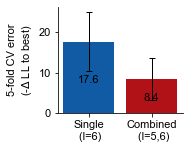

In [48]:
# Get best per model class across different initial conditions
if best_across_inits:
    res_best_train = res_train.groupby(['model_class', 'cvID']).apply(lambda x: x.loc[x['ll_per_step'].idxmin(), ['mle_ll', 'll_per_step', 'sr_id']]).reset_index() 
    res_best_test = res_test.groupby(['model_class', 'cvID']).apply(lambda x: x.loc[x['LL_per_step'].idxmin(), ['LL', 'LL_per_step', 'sr_id']]).reset_index() 
    res_best_fitted = res_fitted.groupby(['model_class']).apply(lambda x: x.loc[x['ll_per_step'].idxmin(), ['mle_ll', 'll_per_step', 'sr_id']]).reset_index()

else:
    # Plotting parameters
    models_with_colors      = pd.DataFrame({'model': full_models_list, 'color': color_list}).drop_duplicates()
    unique_model_types      = models_with_colors['model'].to_list() 
    unique_model_colors     = models_with_colors['color'].to_list()
    color_list_with_alphas  = list(zip(color_list, trans_list))

if best_across_inits:
    color_list_with_alphas = np.unique(color_list)

# Figure 1: Plot LL + LL differences (per step)
plt.style.use('/Users/sbecker/Projects/RL_reward_novelty/src/scripts/Figures_Paper/paper.mplstyle')

path_save = os.path.join(sl.get_datapath().replace('data','output'),f'Figures_Paper_Revised/Fig_model_comp/')
sl.make_long_dir(path_save)

num_panels = 3
f, ax = plt.subplots(1, 1, figsize=(8.3/num_panels, 2.2))

if best_across_inits:
    piv_res_best_train = res_best_train.pivot(index='model_class', columns='cvID', values='ll_per_step')
    piv_res_best_test  = res_best_test.pivot(index='model_class', columns='cvID', values='LL_per_step')
    piv_res_best_train = piv_res_best_train.sort_index(ascending=False)
    piv_res_best_test  = piv_res_best_test.sort_index(ascending=False)
    print(piv_res_best_test)

    # Lower row: Differences to best model
    diff_LL_train = piv_res_best_train.values - np.min(piv_res_best_train.values, axis=0) # difference to best model per fold
    diff_LL_test  = piv_res_best_test.values  - np.min(piv_res_best_test.values, axis=0)  # difference to best model per fold
    diff_LL_fitted = res_best_fitted['ll_per_step'].values - np.min(res_best_fitted['ll_per_step'].values)

    if scale_to_full:
        diff_LL_train = diff_LL_train * n_app
        diff_LL_test = diff_LL_test * n_app
        diff_LL_fitted = diff_LL_fitted * n_app

    y1 = np.mean(diff_LL_train, axis=1)
    y2 = np.mean(diff_LL_test, axis=1)
    y3 = diff_LL_fitted
    se1 = np.std(diff_LL_train, axis=1)/np.sqrt(diff_LL_train.shape[1]) 
    se2 = np.std(diff_LL_test, axis=1)/np.sqrt(diff_LL_test.shape[1]) 

    fmt_bars = '%.1f' if scale_to_full else '%.e'

    bb2 = ax.bar(np.arange(len(y2)), y2, color=color_list)
    ax.bar_label(bb2, label_type='center', rotation='horizontal', fmt=fmt_bars, padding=-2)
    ax.errorbar(np.arange(len(y2)), y2, yerr=se2, fmt='none', ecolor='k', capsize=3)

    ax.spines[['top','right']].set_visible(False)
    # ax.set_xlabel('Model')
    ax.set_xticks(np.arange(len(piv_res_best_train.reset_index().model_class.unique())))
    ax.set_xticklabels(piv_res_best_train.reset_index().model_class.unique())
    # ax.set_ylabel('-$\\Delta$ LL')
    ax.set_ylabel(f'{kfold}-fold CV error\n(-$\\Delta$ LL to best)')

else:
    # Lower row: Differences to best model
    diff_LL_train = LL_train - np.min(LL_train, axis=0) # difference to best model per fold
    diff_LL_test  = LL_test  - np.min(LL_test, axis=0)  # difference to best model per fold
    diff_LL_fitted = LL_fitted - np.min(LL_fitted)      # difference to best fitted model

    y1 = np.mean(diff_LL_train, axis=1) if scale_to_full else np.mean(diff_LL_train, axis=1)/n_app
    y2 = np.mean(diff_LL_test, axis=1) if scale_to_full else np.mean(diff_LL_test, axis=1)/n_app
    y3 = diff_LL_fitted if scale_to_full else diff_LL_fitted/n_app
    se1 = np.std(diff_LL_train, axis=1)/np.sqrt(diff_LL_train.shape[1]) if scale_to_full else np.std(diff_LL_train, axis=1)/(np.sqrt(diff_LL_train.shape[1])*n_app)
    se2 = np.std(diff_LL_test, axis=1)/np.sqrt(diff_LL_test.shape[1]) if scale_to_full else np.std(diff_LL_test, axis=1)/(np.sqrt(diff_LL_test.shape[1])*n_app)

    fmt_bars = '%.2f' if scale_to_full else '%.2e'

    bb2 = ax.bar(np.arange(len(LL_test)), y2, color=color_list_with_alphas)
    # ax.bar_label(bb2, label_type='center', rotation='vertical', fmt=fmt_bars)
    ax.errorbar(np.arange(len(LL_test)), y2, yerr=se2, fmt='none', ecolor='k', capsize=3)

    ax.spines[['top','right']].set_visible(False)
    # ax.set_xlabel('Model')
    ax.set_xticks(np.arange(len(full_models_list)))
    ax.set_xticklabels([])
    ax.set_ylabel(f'{kfold}-fold cross-validation error')

    # leg_h = []
    # for i, (unique_m, color_m) in enumerate(zip(unique_model_types, unique_model_colors)):
    #     label_i = f"{unique_m.split('_')[1]}" + (f"_({unique_m.split('_')[2]})" if len(unique_m.split('_'))>2 else "")
    #     patch_i = mpatches.Patch(color=color_m, label=label_i)
    #     leg_h.append(patch_i)

f.tight_layout()
# f.legend(handles=leg_h, ncol=len(leg_h), handletextpad=0.2, fontsize='small', loc='upper center')
f.savefig(os.path.join(path_save, f'Rosenberg_cv-best_panels-{num_panels}.svg'))

### Plot sum of LL (approximation of model evidence) Fig. 3 F

cvID                              0           1            2            3  \
model_class                                                                 
Counts\n (l=6)           954.187254  394.567921  2821.279382  1375.120047   
Best combined\n (l=5,6)  956.193985  396.607041  2809.546019  1370.502470   

cvID                              4  
model_class                          
Counts\n (l=6)           386.333634  
Best combined\n (l=5,6)  383.455700  


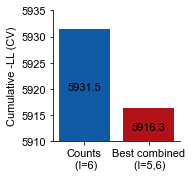

In [76]:
# Get best per model class across different initial conditions
if best_across_inits:
    res_best_train = res_train.groupby(['model_class', 'cvID']).apply(lambda x: x.loc[x['ll_per_step'].idxmin(), ['mle_ll', 'll_per_step', 'sr_id']]).reset_index() 
    res_best_test = res_test.groupby(['model_class', 'cvID']).apply(lambda x: x.loc[x['LL_per_step'].idxmin(), ['LL', 'LL_per_step', 'sr_id']]).reset_index() 
    res_best_fitted = res_fitted.groupby(['model_class']).apply(lambda x: x.loc[x['ll_per_step'].idxmin(), ['mle_ll', 'll_per_step', 'sr_id']]).reset_index()

else:
    # Plotting parameters
    models_with_colors      = pd.DataFrame({'model': full_models_list, 'color': color_list}).drop_duplicates()
    unique_model_types      = models_with_colors['model'].to_list() 
    unique_model_colors     = models_with_colors['color'].to_list()
    color_list_with_alphas  = list(zip(color_list, trans_list))

if best_across_inits:
    color_list_with_alphas = np.unique(color_list)

# Figure 1: Plot LL + LL differences (per step)
plt.style.use('/Users/sbecker/Projects/RL_reward_novelty/src/scripts/Figures_Paper/paper.mplstyle')

path_save = os.path.join(sl.get_datapath().replace('data','output'),f'Figures_Paper_Revised/Fig_model_comp/')
sl.make_long_dir(path_save)

num_panels = 3
f, ax = plt.subplots(1, 1, figsize=(8.3/num_panels-0.3, 2.3))

piv_res_best_train = res_best_train.pivot(index='model_class', columns='cvID', values='mle_ll')
piv_res_best_test  = res_best_test.pivot(index='model_class', columns='cvID', values='LL')
piv_res_best_train = piv_res_best_train.sort_index(ascending=False)
piv_res_best_test  = piv_res_best_test.sort_index(ascending=False)
print(piv_res_best_test)

# Lower row: Differences to best model
sum_LL_train = np.sum(piv_res_best_train.values, axis=1) # difference to best model per fold
sum_LL_test  = np.sum(piv_res_best_test.values, axis=1)  # difference to best model per fold
sum_LL_fitted = np.sum(res_best_fitted['mle_ll'].values)

y1 = sum_LL_train
y2 = sum_LL_test
y3 = sum_LL_fitted

fmt_bars = '%.1f' if scale_to_full else '%.e'

bb2 = ax.bar(np.arange(len(y2)), y2, color=color_list)
ax.bar_label(bb2, label_type='center', rotation='horizontal', fmt=fmt_bars, padding=-2)

ax.spines[['top','right']].set_visible(False)
ax.set_xticks(np.arange(len(piv_res_best_train.reset_index().model_class.unique())))
ax.set_xticklabels(piv_res_best_train.reset_index().model_class.unique())
ax.set_ylabel(f'Cumulative -LL (CV)')
ax.set_ylim([5910, 5935])

f.tight_layout(pad=0.1)
f.savefig(os.path.join(path_save, f'Rosenberg_cv-best_panels-{num_panels}.svg'))

# Plot statistics of behavior for simulated models

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib import cm
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from importlib import reload
import os
import sys
sys.path.append('/lcncluster/becker/RL_reward_novelty')
sys.path.append('/Users/sbecker/Projects/RL_reward_novelty')
import src.utils.saveload as sl

import src.scripts.PPC.steps_to_goal as comp_stg
import src.scripts.PPC.node_ratio as comp_n32
import src.scripts.PPC.dur_per_partition as comp_dpp
import src.scripts.PPC.out_paths as comp_op
import src.scripts.PPC.node_paths as comp_np

In [87]:
# Compute steps to goal for all simulations
model_name_list = ['leaky_hnor'] * 6 + ['leaky_multinov-eps_hnor'] * 4
kernel_type_list = ['notrace'] * len(model_name_list)
level_list = [[6],[5],[4],[3],[2],[1]] + \
              [[[5,6]], [[4,6]], [[3,6]], [[2,6]], [[1,6]]]
sr_id_list = ['_2','_1','_1','_4','_1','_1'] + ['_1','_1','_2','_2','_2'] # '_5' for all levels of hnor, '_3' for all levels of multinov

path_base = '/Volumes/lcncluster/becker/RL_reward_novelty/data/ParameterRecovery4/SimData_uniparam/'
path_sim_list = [os.path.join(path_base, 'leaky_hnor_notrace_app_norew')] *6 + \
                 [os.path.join(path_base, 'leaky_multinov-eps_hnor_notrace_app_norew')] * 4
path_stats = os.path.join(path_base,'stats')

maxit       = 3000          # number of steps included (only relevant for node discovery plots)
num_sim     = 20
no_rew       = False                                    # no_rew = False: include all mice, no_rew = True: include only unrewarded mice

# Paths to model simulation data
# paths_load  = ['/Volumes/lcncluster/becker/RL_reward_novelty/ext_data/Rosenberg2021']
# name_save   = [f'mice_{"expl" if no_rew else "full"}']
# num_sim_all = [list(range(num_sim))]
# thresh_state_ll = [64]
paths_load  = []
name_save   = []
num_sim_all = []
thresh_state_ll = []

for i in range(len(model_name_list)):
    model_name = model_name_list[i]
    level      = level_list[i]
    path_sim   = path_sim_list[i]
    sr_id      = sr_id_list[i]
    kernel_type = kernel_type_list[i]

    for j, level_j in enumerate(level):
        if isinstance(level_j, list):
            level_str = '-'.join([str(lv) for lv in level_j])
        else:
            level_str = str(level_j)
        path_load_ij = os.path.join(path_sim, f'{model_name}_{kernel_type}{sr_id}_app_l{level_str}')
        paths_load.append(path_load_ij)
        name_save.append(f'{model_name}_{kernel_type}{sr_id}_app_l{level_str}')
        num_sim_all.append(list(range(num_sim)))
        thresh_state_ll.append(64)

## Steps to goal + exploration efficiency

In [88]:
# Compute steps to goal #################################################################################################################################################
# Based on all mice (rew / unrew); model / mice behavior is only considered up to the first goal encounter
sl.make_long_dir(os.path.join(path_stats,'steps_to_goal'))
comp_stg.comp_steps_to_goal(path_data_save=os.path.join(path_stats,'steps_to_goal'), paths_load=paths_load, name_save=name_save, no_rew=no_rew, num_sim_ll=num_sim_all, parallel=False, recomp=True)
4
# Compute N32 exploration coefficient ###################################################################################################################################
# Based on all mice (rew / unrew); model / mice behavior is considered up max_it steps
sl.make_long_dir(os.path.join(path_stats,'node_ratio_n32'))
comp_n32.comp_node_ratio_n32(path_data_save=os.path.join(path_stats,'node_ratio_n32'), paths_load=paths_load, name_save=name_save, no_rew=no_rew, maxit=maxit, num_sim_ll=num_sim_all, parallel=False, recomp=True, thresh_state_ll=thresh_state_ll)

Computing steps to goal for leaky_hnor_notrace_2_app_l6...
Finished computing steps to goal for leaky_hnor_notrace_2_app_l6.

Computing steps to goal for leaky_hnor_notrace_1_app_l5...
Finished computing steps to goal for leaky_hnor_notrace_1_app_l5.

Computing steps to goal for leaky_hnor_notrace_1_app_l4...
Finished computing steps to goal for leaky_hnor_notrace_1_app_l4.

Computing steps to goal for leaky_hnor_notrace_4_app_l3...
Finished computing steps to goal for leaky_hnor_notrace_4_app_l3.

Computing steps to goal for leaky_hnor_notrace_1_app_l2...
Finished computing steps to goal for leaky_hnor_notrace_1_app_l2.

Computing steps to goal for leaky_hnor_notrace_1_app_l1...
Finished computing steps to goal for leaky_hnor_notrace_1_app_l1.

Computing steps to goal for leaky_multinov-eps_hnor_notrace_1_app_l5-6...
Finished computing steps to goal for leaky_multinov-eps_hnor_notrace_1_app_l5-6.

Computing steps to goal for leaky_multinov-eps_hnor_notrace_1_app_l4-6...
Finished compu

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

## Time per partition

In [89]:
reload(comp_dpp)

<module 'src.scripts.PPC.dur_per_partition' from '/Users/sbecker/Projects/RL_reward_novelty/src/scripts/PPC/dur_per_partition.py'>

In [90]:
# Compute duration per partition and ratio of center vs. periphery ######################################################################################################
# Based only on unrewarded mice; model / mice behavior is considered up to maxit steps
levels_dpp    = list(range(1,7))
levels_node   = list(range(1,7))

no_rew       = False 
# name_save[0] = f'mice_{"expl" if no_rew else "full"}'
maxit        = 3000  #?????
for i in levels_dpp:
    sl.make_long_dir(os.path.join(path_stats,f'dur_per_partition_l{i}'))
    comp_dpp.comp_dur_per_partition_parallel(path_data_save=os.path.join(path_stats,f'dur_per_partition_l{i}'), paths_load=paths_load, name_save=name_save, num_sim_ll=num_sim_all, levels=[i], parallel=False, recomp=True, recomp_stats=True)

Computing dur per partition for leaky_hnor_notrace_2_app_l6...
Finished computing dur per partition for leaky_hnor_notrace_2_app_l6.

Computing T/partition for leaky_hnor_notrace_2_app_l6...
Finished computing T/partition for leaky_hnor_notrace_2_app_l6.

Computing C vs. P for leaky_hnor_notrace_2_app_l6...
Finished computing C vs. P for leaky_hnor_notrace_2_app_l6.

Return0

Computing dur per partition for leaky_hnor_notrace_1_app_l5...
Finished computing dur per partition for leaky_hnor_notrace_1_app_l5.

Computing T/partition for leaky_hnor_notrace_1_app_l5...
Finished computing T/partition for leaky_hnor_notrace_1_app_l5.

Computing C vs. P for leaky_hnor_notrace_1_app_l5...
Finished computing C vs. P for leaky_hnor_notrace_1_app_l5.

Return1

Computing dur per partition for leaky_hnor_notrace_1_app_l4...
Finished computing dur per partition for leaky_hnor_notrace_1_app_l4.

Computing T/partition for leaky_hnor_notrace_1_app_l4...
Finished computing T/partition for leaky_hnor_notra

In [ ]:
# Length of node-to-node paths ##########################################################################################################################################
# Based only on unrewarded mice; model / mice behavior is considered up to maxit steps
for i in levels_node:
    sl.make_long_dir(os.path.join(path_stats,f'node_paths_l{i}'))
    comp_np.comp_node_paths_parallel(path_data_save=os.path.join(path_stats,f'node_paths_l{i}'), paths_load=paths_load, name_save=name_save, no_rew=no_rew, level=i, parallel=False, recomp=True)

Computing node paths for leaky_hnor_notrace_2_app_l6...
Finished computing node paths for leaky_hnor_notrace_2_app_l6.

Computing node paths for leaky_hnor_notrace_1_app_l5...
Finished computing node paths for leaky_hnor_notrace_1_app_l5.

Computing node paths for leaky_hnor_notrace_1_app_l4...
Finished computing node paths for leaky_hnor_notrace_1_app_l4.

Computing node paths for leaky_hnor_notrace_4_app_l3...
Finished computing node paths for leaky_hnor_notrace_4_app_l3.

Computing node paths for leaky_hnor_notrace_1_app_l2...
Finished computing node paths for leaky_hnor_notrace_1_app_l2.

Computing node paths for leaky_hnor_notrace_1_app_l1...
Finished computing node paths for leaky_hnor_notrace_1_app_l1.

Computing node paths for leaky_multinov-eps_hnor_notrace_1_app_l5-6...
Finished computing node paths for leaky_multinov-eps_hnor_notrace_1_app_l5-6.

Computing node paths for leaky_multinov-eps_hnor_notrace_1_app_l4-6...
Finished computing node paths for leaky_multinov-eps_hnor_n

In [1]:
# Length of in- and out-paths ###########################################################################################################################################
# Based only on unrewarded mice; model / mice behavior is considered up to maxit steps
sl.make_long_dir(os.path.join(path_stats,'out_paths'))
comp_op.comp_out_paths_parallel(path_data_save=os.path.join(path_stats,'out_paths'), paths_load=paths_load, name_save=name_save, no_rew=no_rew, parallel=False, recomp=True)

NameError: name 'sl' is not defined

## Plot

In [38]:
import numpy as np
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
sys.path.append('/Users/sbecker/Projects/RL_reward_novelty/')
sys.path.append('/lcncluster/becker/RL_reward_novelty/')
import src.utils.saveload as sl
import src.utils.visualization as vis
from src.scripts.Figures_Paper.Fig_ppc.steps_to_goal_ppc import plot_steps_to_goal_all
from src.scripts.Figures_Paper.Fig_ppc.node_ratio_ppc import plot_node_ratio_all, plot_N32_all, plot_N32_all_singlestat, plot_integral_diff_all
from src.scripts.Figures_Paper.Fig_ppc.dur_per_partition_ppc import plot_dur_per_partition_all

/var/folders/wv/411_cg655539_0t6mhrytx1w0000gp/T/ipykernel_87992/3070368958.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_b = plt.cm.get_cmap('Blues') # blue (single-distribution)
/var/folders/wv/411_cg655539_0t6mhrytx1w0000gp/T/ipykernel_87992/3070368958.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_r = plt.cm.get_cmap('Reds')  # red (two-distribution)


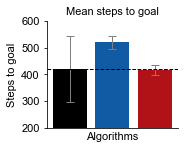

In [49]:
# Load style file
plt.style.use('/Users/sbecker/Projects/RL_reward_novelty/src/scripts/Figures_Paper/paper.mplstyle')

# Folders for saving data and figures
path_data_save = '/Volumes/lcncluster/becker/RL_reward_novelty/data/ParameterRecovery4/SimData_uniparam/stats'
path_fig_save  = '/Users/sbecker/Projects/RL_reward_novelty/output/Figures_Paper_Revised/Fig_ppc'
sl.make_long_dir(path_data_save)
sl.make_long_dir(path_fig_save)

# Folders for loading data
path_exp    = '/Users/sbecker/Projects/RL_reward_novelty/ext_data/Rosenberg2021' # get it from cluster?
path_sim    = '/Volumes/lcncluster/becker/RL_reward_novelty/data/ParameterRecovery4/SimData_uniparam'

# Which plots to make
plot_newnor = True

# Plot first row (hybrid model)
if plot_newnor:
    plot_medians    = False
    lw              = 1
    plot_type   = 'comp_newnor'   # 'mice_only','comp_hyb2','comp_nor','comp_algs'
    no_rew      = False         # if true: include only unrewarded mice
    maxit       = 3000          # number of steps included (only relevant for node discovery plots)
    figsize     = (2.05,2.05)
    
    paths_load  = [path_exp,os.path.join(path_sim,'stats'),os.path.join(path_sim,'stats')]
    legendstr   = ['Mice','Single','Combined']
    savename    = ['mice_expl' if no_rew else 'mice_full','leaky_hnor_notrace_5_app_l6','leaky_multinov-eps_hnor_notrace_3_app_l5-6']
    vmax   = 6
    cnorm  = colors.Normalize(vmin=0, vmax=vmax)
    cmap_b = plt.cm.get_cmap('Blues') # blue (single-distribution)
    smap_b = cm.ScalarMappable(norm=cnorm, cmap=cmap_b)
    cmap_r = plt.cm.get_cmap('Reds')  # red (two-distribution)
    smap_r = cm.ScalarMappable(norm=cnorm, cmap=cmap_r)
    cols        = ['k',smap_b.to_rgba(vmax-1), smap_r.to_rgba(vmax-1)]
    # cols.extend([vis.prep_cmap(name='bwr',num=9)[-1]])
    # cols.extend([vis.prep_cmap(name='Blues',num=len(np.arange(1,7)))[1]])
    # [paths_load.append(os.path.join(path_sim,f'hhybrid2_app_norew/hhybrid2_app_l{ll}')) for ll in range(1,7)]
    # [legendstr.append(f's{ll}-Hyb') for ll in range(1,7)] 
    # [savename.append(f'hhyb2-l{ll}') for ll in range(1,7)]
    # cols.extend(vis.prep_cmap(name='Blues',num=len(np.arange(1,7))))
    # cols.extend(vis.prep_cmap(name='Reds',num=len(np.arange(1,7))))
    # cols.extend(vis.prep_cmap(name='bwr',num=1+2*len(np.arange(1,7)))[:len(np.arange(1,7))])

    f_mean,ax_mean = plt.subplots(1,1,figsize=(8.1/3,2.2))
    ax1 = [ax_mean]
    if plot_medians:
        f_med,ax_med = plt.subplots(1,1,figsize=(8.1/3,2.2))
        ax1.append(ax_med)

    plot_steps_to_goal_all(plot_type, os.path.join(path_data_save, 'steps_to_goal'), path_fig_save, no_rew, paths_load, legendstr, savename, cols, plot_dp=False, recomp=False, cut_outlier=False, axl=ax1, lw=lw, plot_medians=plot_medians)
    # plot_node_ratio_all(plot_type, os.path.join(path_data_save, 'node_ratio_n32'), path_fig_save, maxit, no_rew, paths_load, legendstr, savename, cols, plot_dp=False, window_size=5,recomp=False, axl=ax1, lw=lw)
    # plot_N32_all_singlestat(plot_type, os.path.join(path_data_save, 'node_ratio_n32'), path_fig_save, maxit, no_rew, paths_load, legendstr, savename, cols, plot_dp=True, recomp=True, axl=ax1, lw=lw)
    # plot_integral_diff_all(plot_type, os.path.join(path_data_save, 'node_ratio_n32'), path_fig_save, maxit, no_rew, paths_load, legendstr, savename, cols, recomp_ratios=False, recomp=True, plot_medians=plot_medians, axl=ax3, lw=lw)
    # plot_dur_per_partition_all(plot_type, path_data_save, path_fig_save, maxit, no_rew, paths_load, legendstr, savename, cols, plot_dp=False, recomp=False, recomp_stats=False, dpp_level=5, plot_medians=plot_medians, axl=ax3, lw=lw)

    ax_mean.set_ylim(200,600)
    ax_mean.spines[['top', 'right']].set_visible(False)
    ax_mean.set_ylabel('Steps to goal')
    ax_mean.set_yscale('linear')
    f_mean.tight_layout()
    f_mean.savefig(os.path.join(path_fig_save,f'stg_{plot_type}_mean.svg'))
    f_mean.savefig(os.path.join(path_fig_save,f'stg_{plot_type}_mean.eps'))

    if plot_medians:
        f_med.tight_layout()
        f_med.savefig(os.path.join(path_fig_save,f'stg_{plot_type}_median.svg'))
        f_med.savefig(os.path.join(path_fig_save,f'stg_{plot_type}_median.eps'))

# OTHER